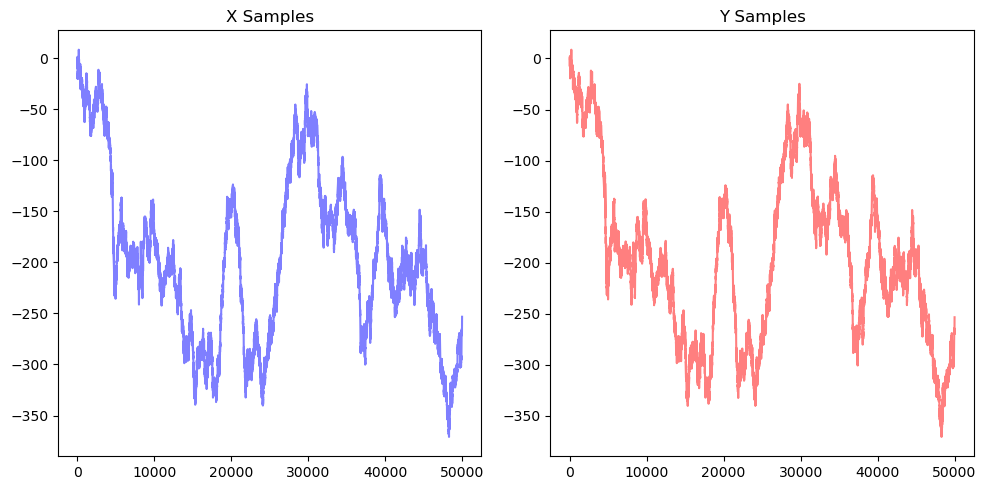

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir las medias y varianzas condicionales
mu_X_given_Y = 0
sigma_X_given_Y = 1
mu_Y_given_X = 0
sigma_Y_given_X = 1

# Número de muestras
N = 50000

# Inicializar las cadenas
x_samples = np.zeros(N)
y_samples = np.zeros(N)
y_samples[0] = np.random.normal(mu_Y_given_X, sigma_Y_given_X)  # Valor inicial arbitrario para Y

# Gibbs Sampling
for i in range(1, N):
    # Muestrear X | Y
    x_samples[i] = np.random.normal(mu_X_given_Y + y_samples[i-1], sigma_X_given_Y)
    # Muestrear Y | X
    y_samples[i] = np.random.normal(mu_Y_given_X + x_samples[i], sigma_Y_given_X)

# Visualización
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x_samples, 'b', alpha=0.5, label='X samples')
plt.title('X Samples')
plt.subplot(1, 2, 2)
plt.plot(y_samples, 'r', alpha=0.5, label='Y samples')
plt.title('Y Samples')
plt.tight_layout()
plt.show()


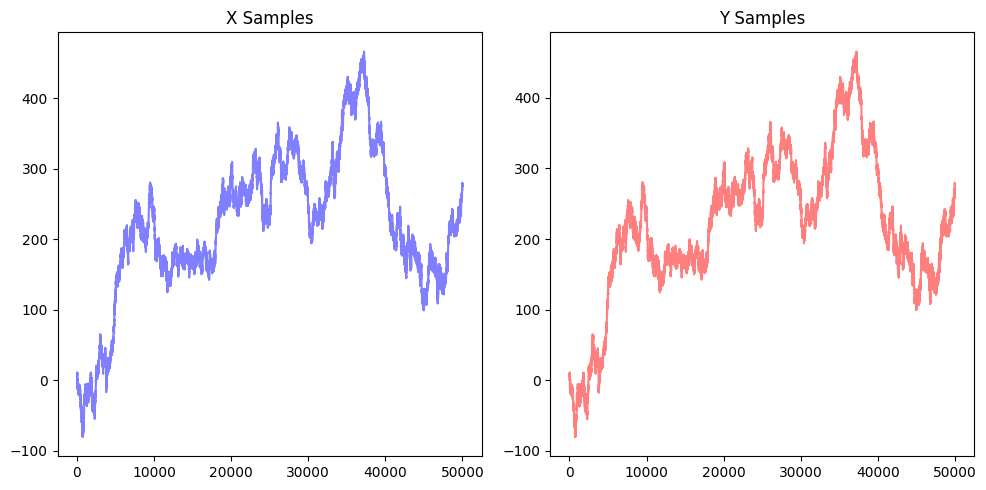

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de Parámetros para las distribuciones condicionales
# Estas son nuestras "priors" en este escenario simplificado.
mu_X_given_Y = 0  # Media de X dado Y
sigma_X_given_Y = 1  # Varianza de X dado Y
mu_Y_given_X = 0  # Media de Y dado X
sigma_Y_given_X = 1  # Varianza de Y dado X

# Inicialización
N = 50000  # Número de iteraciones para el Gibbs Sampling
x_samples = np.zeros(N)  # Almacenamiento para las muestras de X
y_samples = np.zeros(N)  # Almacenamiento para las muestras de Y
y_samples[0] = np.random.normal(mu_Y_given_X, sigma_Y_given_X)  # Valor inicial para Y

# Bucle de Gibbs Sampling
for i in range(1, N):
    # Muestreo de X dado el valor actual de Y
    x_samples[i] = np.random.normal(mu_X_given_Y + y_samples[i-1], sigma_X_given_Y)
    # Muestreo de Y dado el nuevo valor de X
    y_samples[i] = np.random.normal(mu_Y_given_X + x_samples[i], sigma_Y_given_X)

# Visualización de las muestras
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x_samples, 'b', alpha=0.5, label='X samples')
plt.title('X Samples')
plt.subplot(1, 2, 2)
plt.plot(y_samples, 'r', alpha=0.5, label='Y samples')
plt.title('Y Samples')
plt.tight_layout()
plt.show()


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

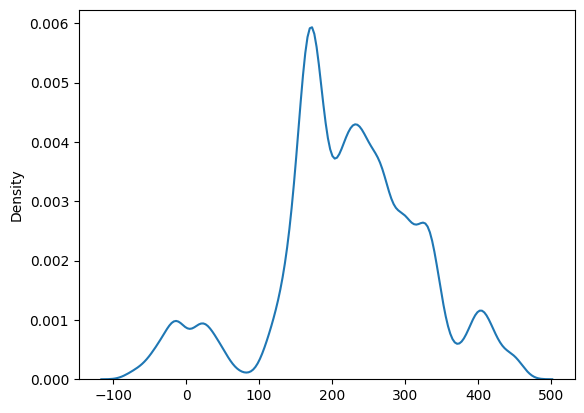

In [3]:
### plot density
import seaborn as sns
sns.kdeplot(x_samples, label='X samples')

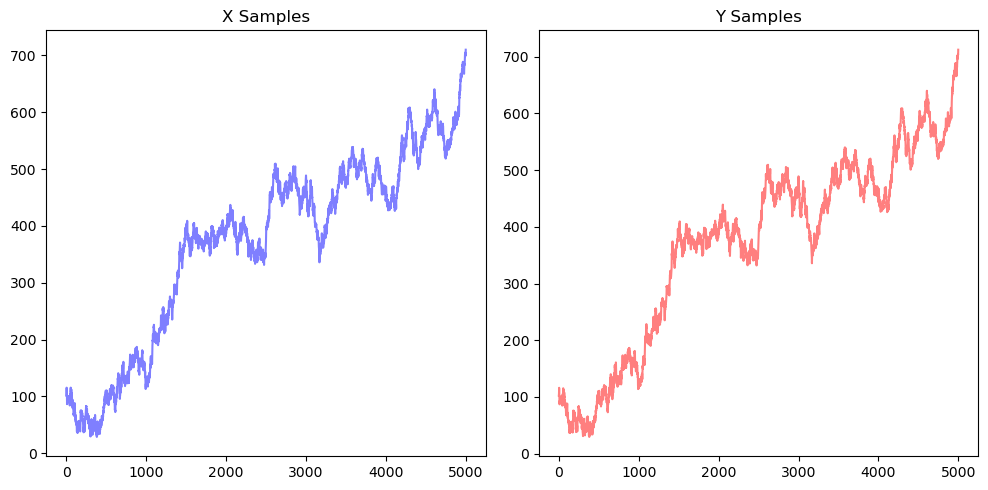

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros ajustados basados en información previa o diagnósticos
mu_X_given_Y = 0  # Ajusta según lo necesario
sigma_X_given_Y = 1  # Considera ajustar basado en diagnósticos preliminares
mu_Y_given_X = 0
sigma_Y_given_X = 1

# Inicialización y configuración mejoradas
N = 60000
burn_in = 10000
thinning = 10
x_samples = np.zeros(N)
y_samples = np.zeros(N)
y_samples[0] = np.random.normal(mu_Y_given_X, sigma_Y_given_X)  # Considera una inicialización más informada

for i in range(1, N):
    x_samples[i] = np.random.normal(mu_X_given_Y + y_samples[i-1], sigma_X_given_Y)
    y_samples[i] = np.random.normal(mu_Y_given_X + x_samples[i], sigma_Y_given_X)

# Aplicando quemado y thinning
x_samples = x_samples[burn_in::thinning]
y_samples = y_samples[burn_in::thinning]

# Implementa diagnósticos de convergencia aquí

# Visualización mejorada
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x_samples, 'b', alpha=0.5)
plt.title('X Samples')
plt.subplot(1, 2, 2)
plt.plot(y_samples, 'r', alpha=0.5)
plt.title('Y Samples')
plt.tight_layout()
plt.show()


In [14]:
import numpy as np
from scipy.stats import beta, binom

# Parámetros de simulación y distribuciones
Nsim = 5000
n = 15
a = 3
b = 7

# Inicialización de arrays
X = np.zeros(Nsim)
T = np.zeros(Nsim)

# Generar la primera muestra
T[0] = beta.rvs(a, b)
X[0] = binom.rvs(n, T[0])

# Bucle de simulación
for i in range(1, Nsim):
    X[i] = binom.rvs(n, T[i-1])
    T[i] = beta.rvs(a + X[i], n - X[i] + b)

# Resultados
print("X (primeras 10 muestras):", X[:10])
print("T (primeras 10 muestras):", T[:10])


X (primeras 10 muestras): [5. 4. 5. 5. 5. 1. 2. 4. 1. 1.]
T (primeras 10 muestras): [0.37090415 0.49539208 0.35023528 0.20506599 0.10099869 0.22002242
 0.37344611 0.21096231 0.06059516 0.19860143]


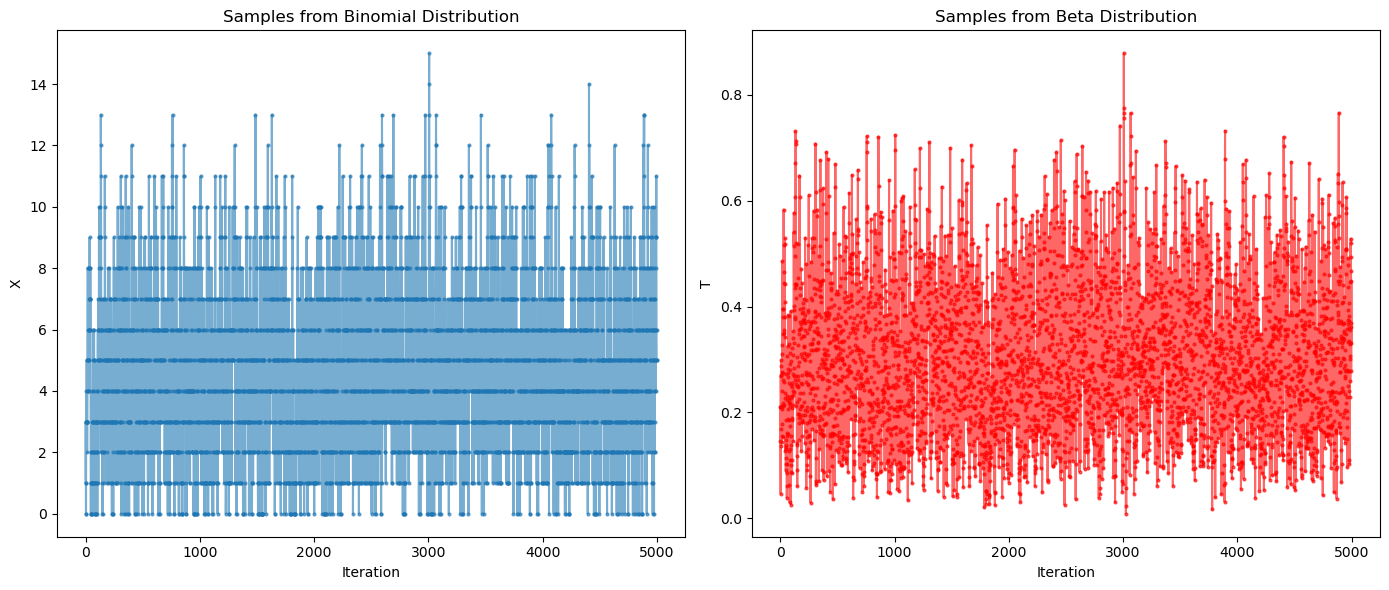

In [4]:
import matplotlib.pyplot as plt

# Asumiendo que X y T han sido generados por el bloque de código anterior

# Gráfico de las muestras de X
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(X, marker='o', linestyle='-', markersize=2, alpha=0.6, label='X samples')
plt.title('Samples from Binomial Distribution')
plt.xlabel('Iteration')
plt.ylabel('X')

# Gráfico de las muestras de T
plt.subplot(1, 2, 2)
plt.plot(T, marker='o', linestyle='-', markersize=2, alpha=0.6, color='r', label='T samples')
plt.title('Samples from Beta Distribution')
plt.xlabel('Iteration')
plt.ylabel('T')

plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


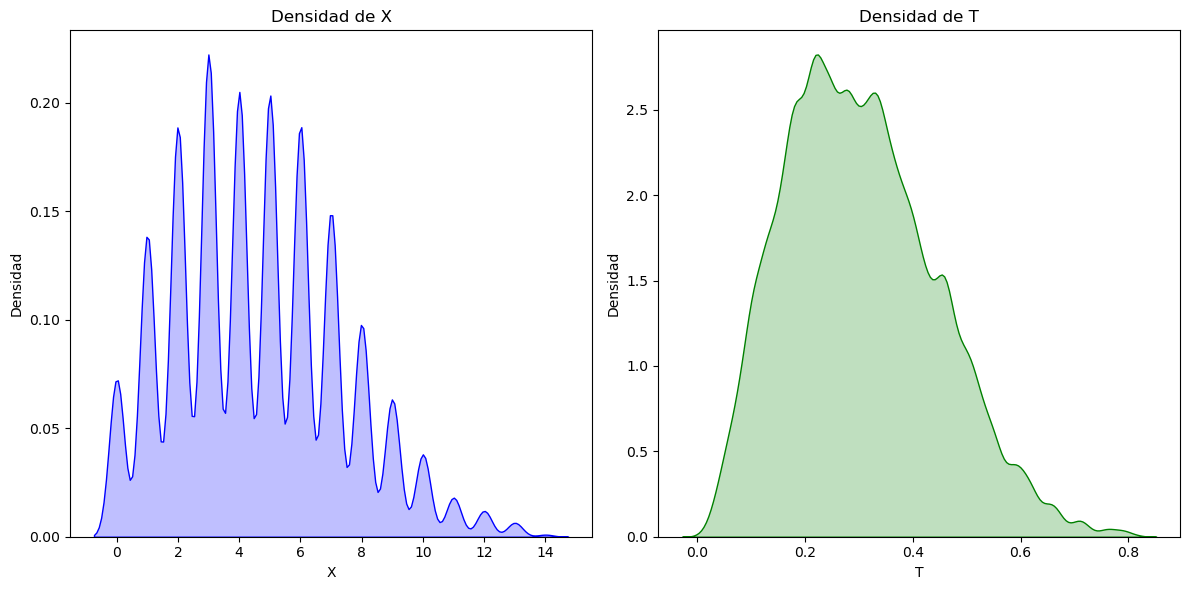

In [15]:
import numpy as np
from scipy.stats import beta, binom
import matplotlib.pyplot as plt
import seaborn as sns

# Parámetros de simulación y distribuciones
Nsim = 5000
n = 15
a = 3
b = 7

# Inicialización de arrays
X = np.zeros(Nsim)
T = np.zeros(Nsim)

# Generar la primera muestra
T[0] = beta.rvs(a, b)
X[0] = binom.rvs(n, T[0])

# Bucle de simulación
for i in range(1, Nsim):
    X[i] = binom.rvs(n, T[i-1])
    T[i] = beta.rvs(a + X[i], n - X[i] + b)

# Gráficos de densidad
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(X, bw_adjust=0.5, color='blue', fill=True)
plt.title('Densidad de X')
plt.xlabel('X')
plt.ylabel('Densidad')

plt.subplot(1, 2, 2)
sns.kdeplot(T, bw_adjust=0.5, color='green', fill=True)
plt.title('Densidad de T')
plt.xlabel('T')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()


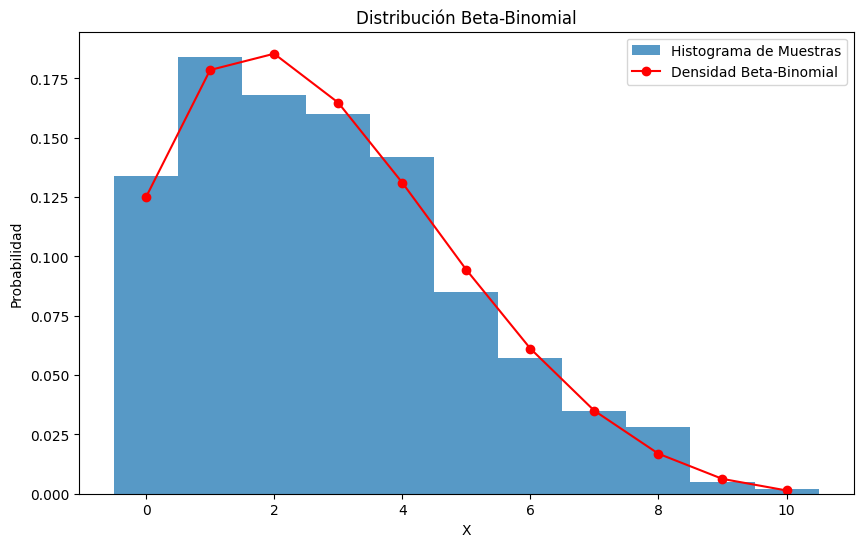

In [12]:
import numpy as np
from scipy.stats import betabinom
import matplotlib.pyplot as plt

def betabi(x, a, b, n):
    """Calcula la densidad de probabilidad beta-binomial para x dado n, a, y b."""
    # Utiliza la función betabinom de scipy.stats para calcular la PMF
    return betabinom.pmf(x, n, a, b)

# Parámetros de ejemplo
a = 2
b = 5
n = 10

# Valores de x
x_values = np.arange(0, n+1)

# Calcula la PMF beta-binomial para cada valor de x
pmf_values = betabi(x_values, a, b, n)

# Visualización
plt.figure(figsize=(10, 6))

# Histograma de muestras beta-binomiales (simulado)
samples = betabinom.rvs(n, a, b, size=1000)
plt.hist(samples, bins=np.arange(n+2)-0.5, density=True, alpha=0.75, label='Histograma de Muestras')

# Curva de la PMF beta-binomial
plt.plot(x_values, pmf_values, 'ro-', label='Densidad Beta-Binomial')

plt.title('Distribución Beta-Binomial')
plt.xlabel('X')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()


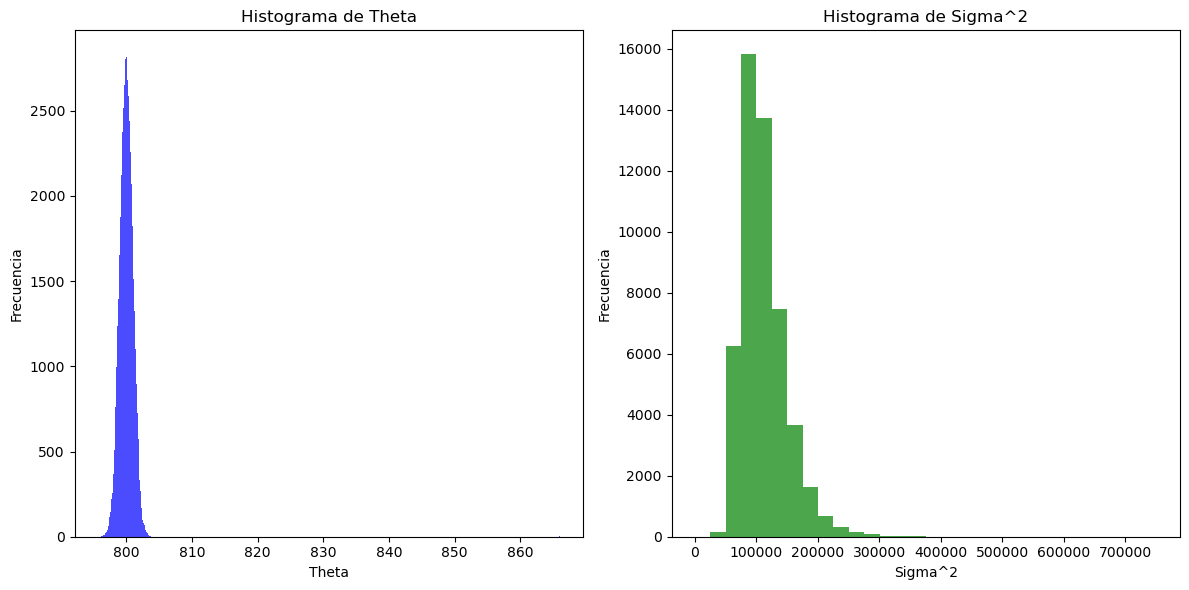

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

# Datos observados
x = np.array([91, 504, 557, 609, 693, 727, 764, 803, 857, 929, 970, 1043,
              1089, 1195, 1384, 1713])

# Parámetros iniciales
Nsim = 50000
n = len(x)
a = 3
b = 7
tau2 = 1  # Este valor necesita ser definido, asumiendo tau2 = 1 para el ejemplo
theta0 = 800  # Asumiendo theta0 como la media de x para el ejemplo

# Inicializaciones
sigma2 = np.zeros(Nsim)
theta = np.zeros(Nsim)
xbar = np.mean(x)

# Inicialización de la primera iteración
sigma2[0] = 1 / gamma.rvs(a, scale=1/b)  # Nota: scale en scipy es 1/rate
B = sigma2[0] / (sigma2[0] + n * tau2)
theta[0] = norm.rvs(loc=B*theta0 + (1-B)*xbar, scale=np.sqrt(tau2*B))

# Bucle de muestreo
for i in range(1, Nsim):
    B = sigma2[i-1] / (sigma2[i-1] + n * tau2)
    theta[i] = norm.rvs(loc=B*theta0 + (1-B)*xbar, scale=np.sqrt(tau2*B))
    ra1 = (1/2) * np.sum((x - theta[i])**2) + b
    sigma2[i] = 1 / gamma.rvs((n/2) + a, scale=1/ra1)

# Gráficos de los resultados
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(theta, bins=500, alpha=0.7, color='blue')
plt.title('Histograma de Theta')
plt.xlabel('Theta')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(sigma2, bins=30, alpha=0.7, color='green')
plt.title('Histograma de Sigma^2')
plt.xlabel('Sigma^2')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


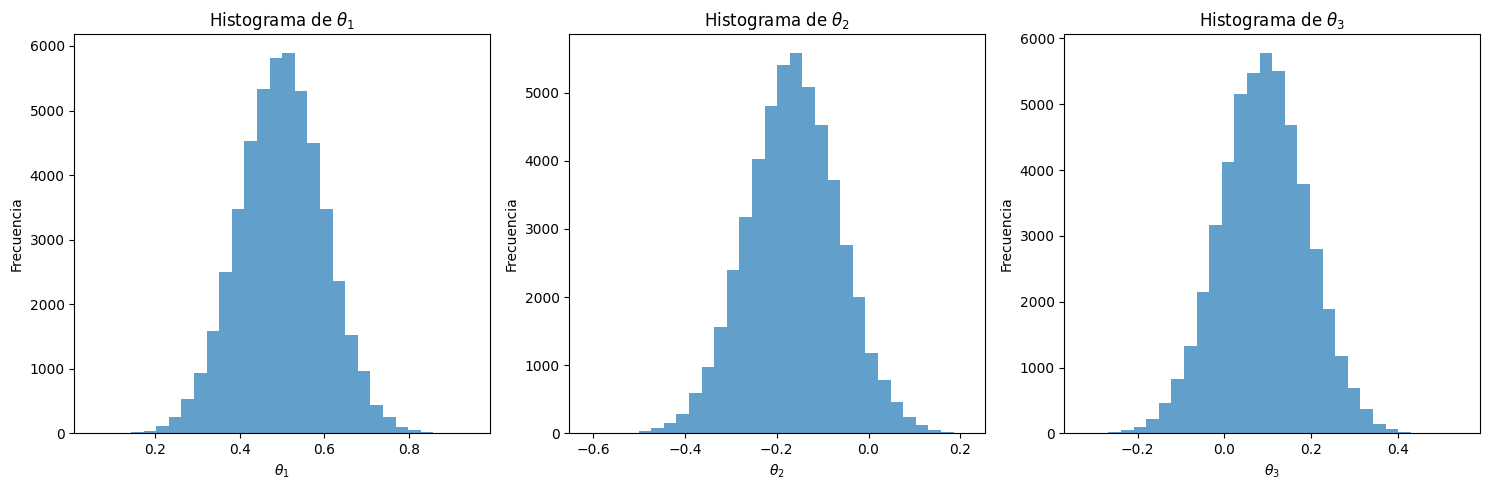

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Simulando datos
np.random.seed(42)
n = 100  # Número de observaciones
real_theta = np.array([0.5, -0.2, 0.3])  # Los verdaderos valores de theta para generación de datos
Sigma = np.array([[1, 0.1, 0.1], [0.1, 1, 0.1], [0.1, 0.1, 1]])  # Matriz de covarianza conocida
X_obs = np.random.multivariate_normal(real_theta, Sigma, size=n)

# Asumimos priors normales para theta_i
mu_prior = np.array([0, 0, 0])  # Medias de los priors
sigma_prior = np.array([10, 10, 10])  # Desviaciones estándar de los priors

# Función de actualización para el Muestreo de Gibbs
def gibbs_sampling_improved(X, n_iter=50000):
    n, d = X.shape  # número de observaciones y dimensiones
    theta_samples = np.zeros((n_iter, d))  # Para almacenar muestras de theta
    sigma_posterior = 0.1  # Simulamos una "varianza posterior" para las actualizaciones
    
    for i in range(n_iter):
        for j in range(d):
            # Simulamos la actualización del parámetro theta_i
            # Aquí se utilizaría la fórmula de actualización de la distribución posterior si fuera un ejemplo completo
            mean_posterior = np.mean(X[:, j])  # Usamos la media de las observaciones como un sustituto simplificado
            theta_samples[i, j] = np.random.normal(mean_posterior, sigma_posterior)
    
    return theta_samples

# Realizar el muestreo mejorado
theta_samples = gibbs_sampling_improved(X_obs)

# Visualización de los resultados
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(theta_samples[:, i], bins=30, alpha=0.7)
    plt.title(f'Histograma de $\\theta_{i+1}$')
    plt.xlabel(f'$\\theta_{i+1}$')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


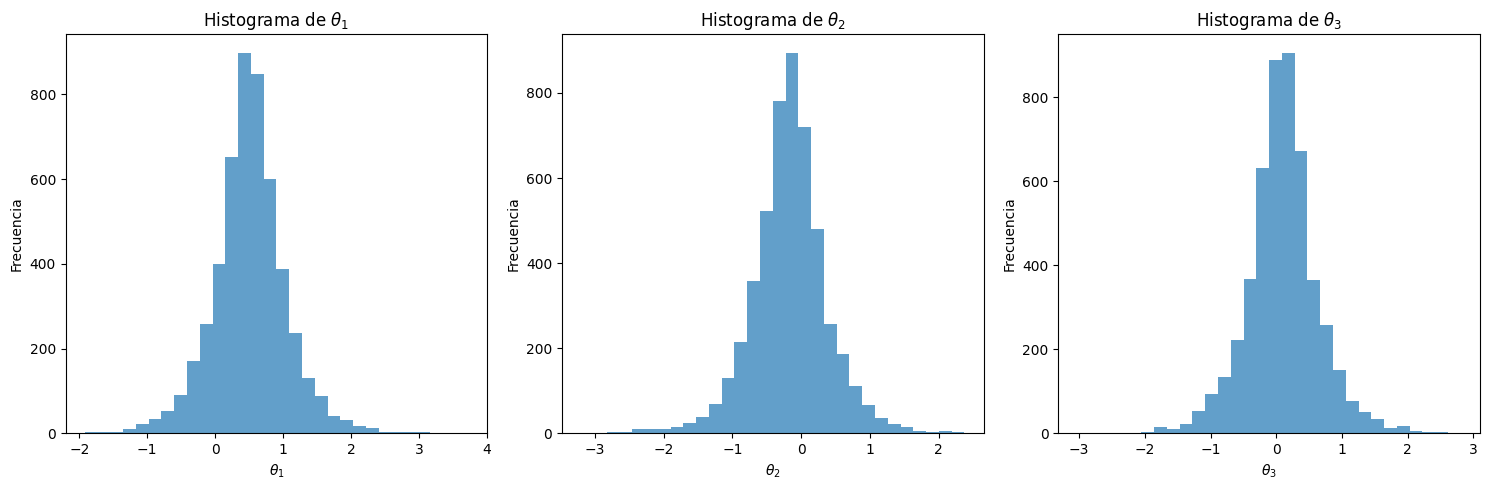

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wishart

# Simulando datos
np.random.seed(42)
n = 100  # Número de observaciones
d = 3  # Número de parámetros
real_theta = np.array([0.5, -0.2, 0.3])
Sigma = np.array([[1, 0.1, 0.1], [0.1, 1, 0.1], [0.1, 0.1, 1]])
X_obs = np.random.multivariate_normal(real_theta, Sigma, size=n)

# Configuración de la Wishart
degrees_of_freedom = d  # Grados de libertad
scale_matrix = np.eye(d) * 0.1  # Matriz de escala, ajustada para reflejar una varianza pequeña

# Función de actualización para el Muestreo de Gibbs usando Wishart
def gibbs_sampling_with_wishart(X, n_iter=5000):
    n, d = X.shape
    theta_samples = np.zeros((n_iter, d))
    
    for i in range(n_iter):
        # Simulamos la matriz de covarianza posterior para este paso
        Sigma_posterior = wishart.rvs(df=degrees_of_freedom, scale=scale_matrix)
        for j in range(d):
            mean_posterior = np.mean(X[:, j])
            # Usamos la diagonal de Sigma_posterior como las varianzas individuales para las actualizaciones
            theta_samples[i, j] = np.random.normal(mean_posterior, np.sqrt(Sigma_posterior[j, j]))
    
    return theta_samples

# Realizar el muestreo
theta_samples = gibbs_sampling_with_wishart(X_obs)

# Visualización de los resultados
plt.figure(figsize=(15, 5))
for i in range(d):
    plt.subplot(1, 3, i+1)
    plt.hist(theta_samples[:, i], bins=30, alpha=0.7)
    plt.title(f'Histograma de $\\theta_{i+1}$')
    plt.xlabel(f'$\\theta_{i+1}$')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


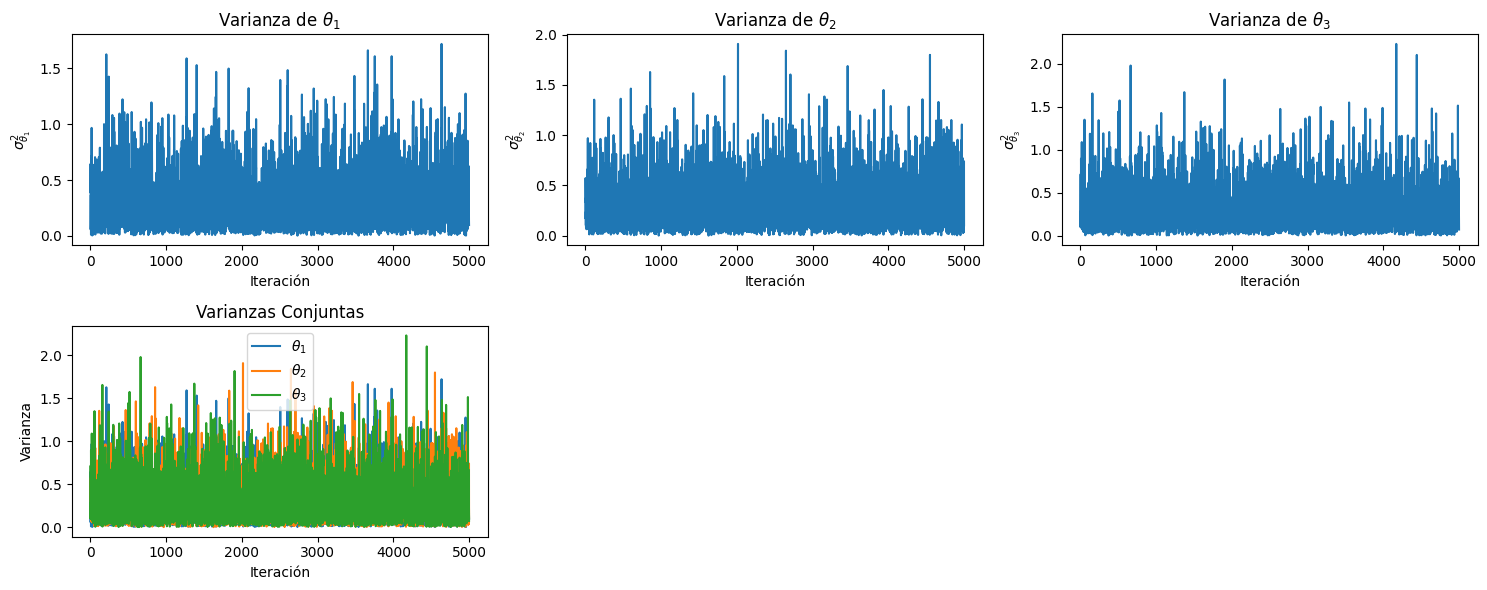

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wishart

# Configuración inicial
np.random.seed(42)
n = 100  # Número de observaciones
d = 3  # Número de parámetros
real_theta = np.array([0.5, -0.2, 0.3])
Sigma = np.array([[1, 0.1, 0.1], [0.1, 1, 0.1], [0.1, 0.1, 1]])
X_obs = np.random.multivariate_normal(real_theta, Sigma, size=n)

# Configuración de la Wishart
degrees_of_freedom = d
scale_matrix = np.eye(d) * 0.1

# Función de actualización modificada para almacenar varianzas
def gibbs_sampling_with_wishart(X, n_iter=5000):
    n, d = X.shape
    theta_samples = np.zeros((n_iter, d))
    sigma_samples = np.zeros((n_iter, d))  # Almacenamiento para las varianzas
    
    for i in range(n_iter):
        Sigma_posterior = wishart.rvs(df=degrees_of_freedom, scale=scale_matrix)
        sigma_samples[i, :] = np.diag(Sigma_posterior)  # Almacenar las varianzas (diagonal de Sigma_posterior)
        for j in range(d):
            mean_posterior = np.mean(X[:, j])
            theta_samples[i, j] = np.random.normal(mean_posterior, np.sqrt(Sigma_posterior[j, j]))
    
    return theta_samples, sigma_samples

# Realizar el muestreo y obtener las varianzas
theta_samples, sigma_samples = gibbs_sampling_with_wishart(X_obs)

# Visualización de las varianzas
plt.figure(figsize=(15, 6))

# Varianzas individuales
for i in range(d):
    plt.subplot(2, 3, i+1)
    plt.plot(sigma_samples[:, i])
    plt.title(f'Varianza de $\\theta_{i+1}$')
    plt.xlabel('Iteración')
    plt.ylabel(f'$\sigma^2_{{\\theta_{i+1}}}$')

# Varianzas conjuntas en una sola gráfica
plt.subplot(2, 3, 4)
for i in range(d):
    plt.plot(sigma_samples[:, i], label=f'$\\theta_{i+1}$')
plt.title('Varianzas Conjuntas')
plt.xlabel('Iteración')
plt.ylabel('Varianza')
plt.legend()

plt.tight_layout()
plt.show()


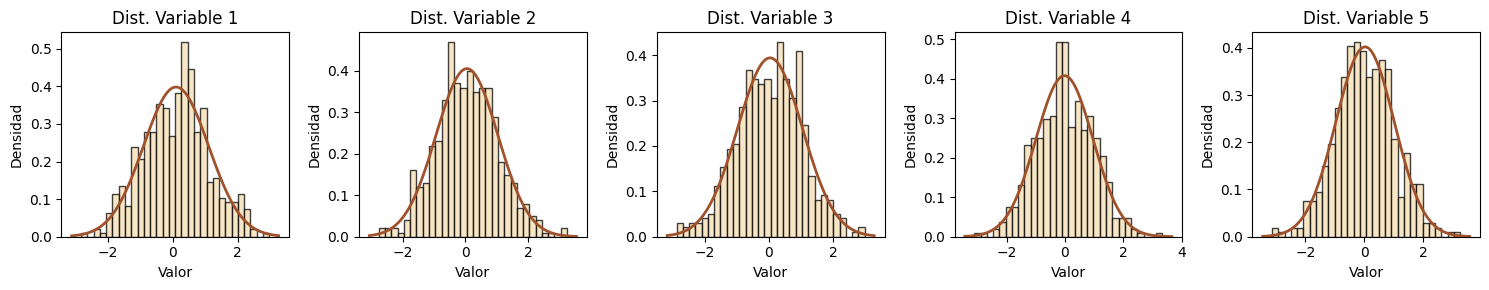

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros de configuración
T = 500  # Número de iteraciones temporales
p = 5  # Número de variables
r = 0.25  # Coeficiente de correlación

# Inicialización
cur = np.random.normal(size=p)  # Estado actual de las variables
X = cur.copy()  # Almacenar el estado inicial

# Bucle de simulación
for t in range(1, T):
    for j in range(p):
        m = np.mean(np.delete(cur, j))  # Media de las otras variables
        sd = np.sqrt((1 + (p-2)*r - (p-1)*r**2) / (1 + (p-2)*r))  # Desviación estándar
        cur[j] = np.random.normal((p-1)*r*m / (1 + (p-2)*r), sd)  # Actualizar variable
    X = np.vstack((X, cur))  # Añadir el estado actualizado

# Visualización
plt.figure(figsize=(15, 3))
for i in range(p):
    plt.subplot(1, p, i+1)
    data = X[:, i]
    plt.hist(data, bins=30, density=True, color="wheat", alpha=0.75, edgecolor='black')
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    y = norm.pdf(x, np.mean(data), np.std(data))  # Curva de densidad normal con la media y desvío estándar de los datos
    plt.plot(x, y, color="sienna", lw=2)
    plt.title(f'Dist. Variable {i+1}')
    plt.xlabel('Valor')
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()


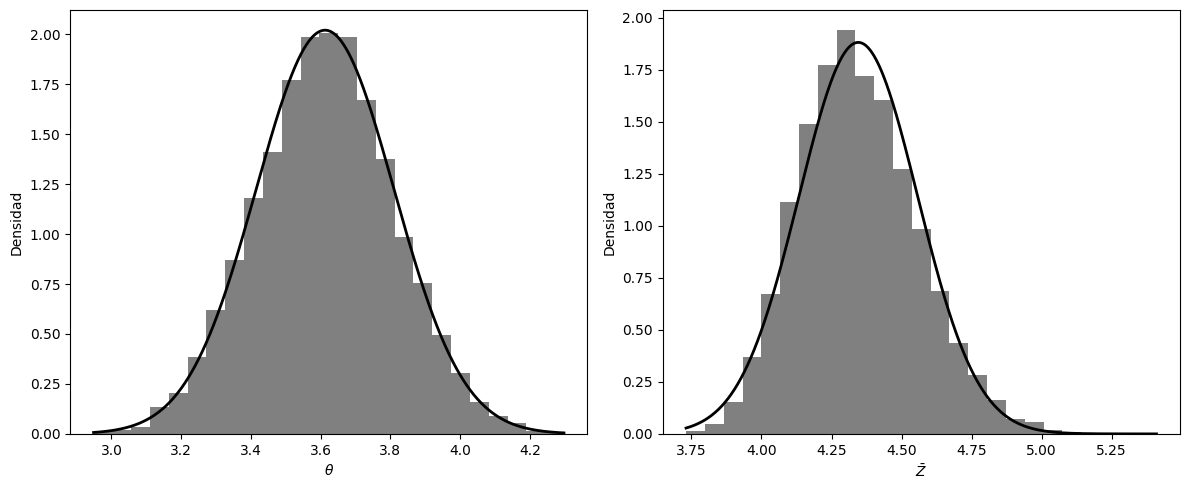

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Datos iniciales y parámetros
xdata = np.array([3.64, 2.78, 2.91, 2.85, 2.54, 2.62, 3.16, 2.21, 4.05, 2.19,
                  2.97, 4.32, 3.56, 3.39, 3.59, 4.13, 4.21, 1.68, 3.88, 4.33])
m = len(xdata)  # Número de datos observados
n = 30  # Total de datos, incluidos los faltantes
a = 3.5  # Umbral para los datos faltantes
nsim = 10000  # Número de simulaciones
xbar = np.mean(xdata)  # Promedio de los datos observados

# Inicialización de las simulaciones
that = np.full(nsim, xbar)  # Inicializa theta con el promedio de los datos observados
zbar = np.full(nsim, a)  # Inicializa zbar con el valor de 'a'

# Bucle de simulación
for i in range(1, nsim):
    temp = np.random.uniform(norm.cdf(a, loc=that[i-1], scale=1), 1, n-m)
    zbar[i] = np.mean(norm.ppf(temp, loc=that[i-1], scale=1))
    that[i] = np.random.normal((m*xbar + (n-m)*zbar[i]) / n, np.sqrt(1/n))

# Visualización
plt.figure(figsize=(12, 5))

# Histograma de theta
plt.subplot(1, 2, 1)
plt.hist(that[500:], bins=25, color="grey", density=True)
x = np.linspace(np.min(that[500:]), np.max(that[500:]), 1000)
plt.plot(x, norm.pdf(x, np.mean(that[500:]), np.std(that[500:])), 'k', lw=2)
plt.xlabel(r'$\theta$')
plt.ylabel('Densidad')

# Histograma de zbar
plt.subplot(1, 2, 2)
plt.hist(zbar[500:], bins=25, color="grey", density=True)
x = np.linspace(np.min(zbar[500:]), np.max(zbar[500:]), 1000)
plt.plot(x, norm.pdf(x, np.mean(zbar[500:]), np.std(zbar[500:])), 'k', lw=2)
plt.xlabel(r'$\bar{Z}$')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()


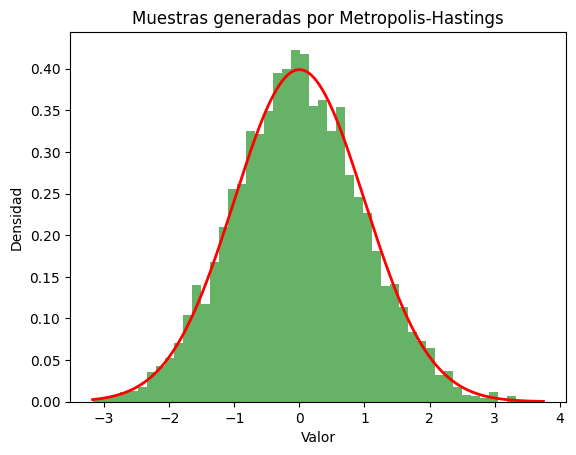

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Definir la función objetivo (distribución normal en este ejemplo)
mu = 0  # Media de la distribución objetivo
sigma = 1  # Desviación estándar de la distribución objetivo
p = lambda x: np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))  # PDF normalizado

# Inicialización
x0 = np.random.normal(0, 1)  # Punto inicial
samples = [x0]
N = 10000  # Número de muestras a generar

# Distribución propuesta: Normal centrada en el estado actual con desviación estándar 1
proposal_std = 1

for i in range(1, N):
    # Generar estado candidato a partir de la distribución propuesta
    x_prime = np.random.normal(samples[-1], proposal_std)
    
    # Calcular la razón de aceptación (simplificada para dos normales)
    alpha = p(x_prime) / p(samples[-1])
    
    # Decidir si se acepta el candidato
    if np.random.rand() < min(1, alpha):
        samples.append(x_prime)
    else:
        samples.append(samples[-1])

# Visualizar las muestras generadas
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')
x = np.linspace(min(samples), max(samples), 1000)
plt.plot(x, p(x), 'r-', lw=2)  # Densidad real
plt.title('Muestras generadas por Metropolis-Hastings')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.show()


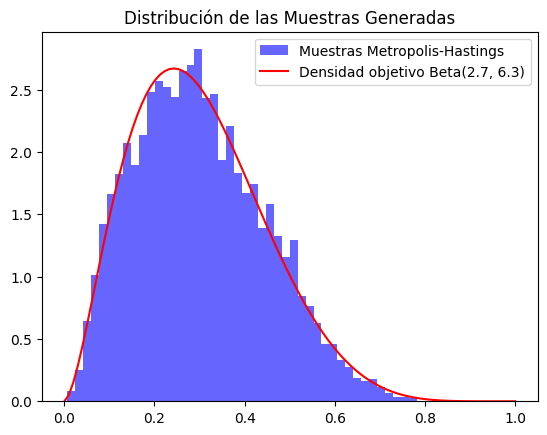

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, uniform

# Parámetros para la distribución Beta objetivo
a, b = 2.7, 6.3

# Número de muestras a generar
N = 10000

# Estado inicial
x = np.zeros(N)
x[0] = np.random.rand()  # Punto de inicio aleatorio en U[0,1]

# Metropolis-Hastings
for i in range(1, N):
    y = uniform.rvs()  # Propuesta de U[0,1]
    alpha = beta.pdf(y, a, b) / beta.pdf(x[i-1], a, b)  # Cociente de aceptación
    
    if uniform.rvs() < alpha:  # Decisión de aceptación
        x[i] = y  # Aceptar propuesta
    else:
        x[i] = x[i-1]  # Rechazar propuesta, mantener estado anterior

# Visualización de las muestras generadas
plt.hist(x, bins=50, density=True, alpha=0.6, color='b', label='Muestras Metropolis-Hastings')
y = np.linspace(0, 1, 100)
plt.plot(y, beta.pdf(y, a, b), 'r-', label='Densidad objetivo Beta(2.7, 6.3)')
plt.legend()
plt.title('Distribución de las Muestras Generadas')
plt.show()
